<a href="https://colab.research.google.com/github/ChAbid-773/Credit_Card_Fruad/blob/main/Credit_Card_Fruad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

In [ ]:
import kagglehub
path = kagglehub.dataset_download("miadul/credit-card-fraud-detection-dataset")

100%|██████████| 111k/111k [00:00<00:00, 53.2MB/s]

Extracting files...


In [ ]:
credit=pd.read_csv(os.path.join(path,'credit_card_fraud_10k.csv'))

In [ ]:
credit

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
coder=LabelEncoder()

In [ ]:
credit['merchant_category']=credit['merchant_category'].astype(str)
credit['merchant_category']=coder.fit_transform(credit['merchant_category'])

In [ ]:
credit

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,1,0,0,66,3,40,0
1,2,541.82,3,4,1,0,87,1,64,0
2,3,237.01,17,3,0,0,49,1,61,0
3,4,164.33,4,3,0,1,72,3,34,0
4,5,30.53,15,2,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,2,0,0,99,4,37,0
9996,9997,410.04,5,0,0,0,70,3,25,0
9997,9998,527.75,21,1,0,0,44,2,45,0
9998,9999,91.20,2,1,0,0,38,0,37,0


In [ ]:
x=(credit.drop('is_fraud',axis=1))
y=(credit['is_fraud'])

In [ ]:
y

,is_fraud
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#**Matplotlib Plot**

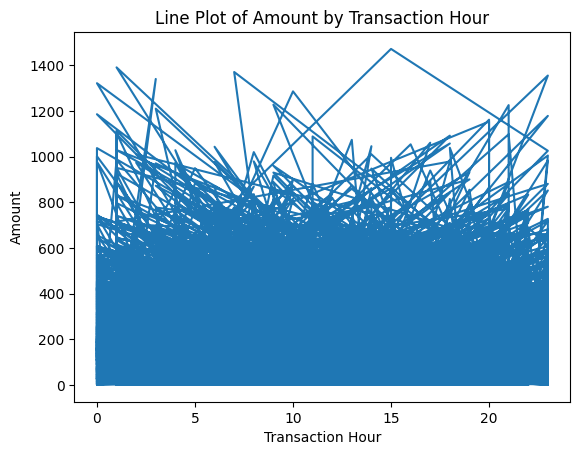

In [ ]:
plt.plot(credit['transaction_hour'], credit['amount'])
plt.title('Line Plot of Amount by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Amount')
plt.show()

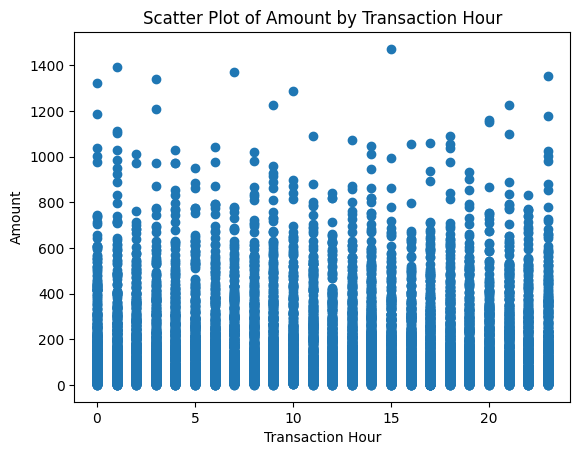

In [ ]:
plt.scatter(credit['transaction_hour'], credit['amount'])
plt.title('Scatter Plot of Amount by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Amount')
plt.show()

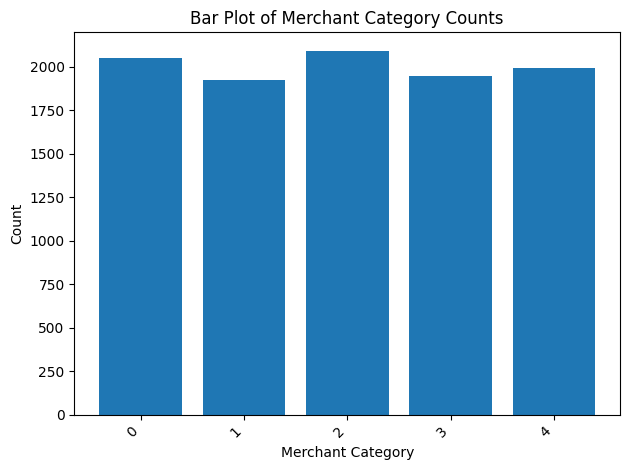

In [ ]:
plt.bar(credit['merchant_category'].value_counts().index, credit['merchant_category'].value_counts().values)
plt.title('Bar Plot of Merchant Category Counts')
plt.xlabel('Merchant Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

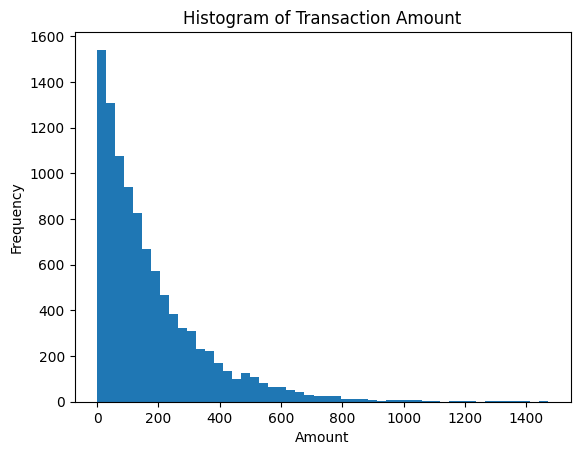

In [ ]:
plt.hist(credit['amount'], bins=50)
plt.title('Histogram of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

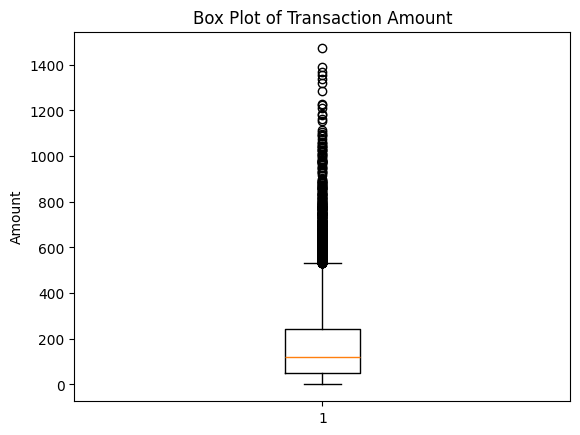

In [ ]:
plt.boxplot(credit['amount'])
plt.title('Box Plot of Transaction Amount')
plt.ylabel('Amount')
plt.show()

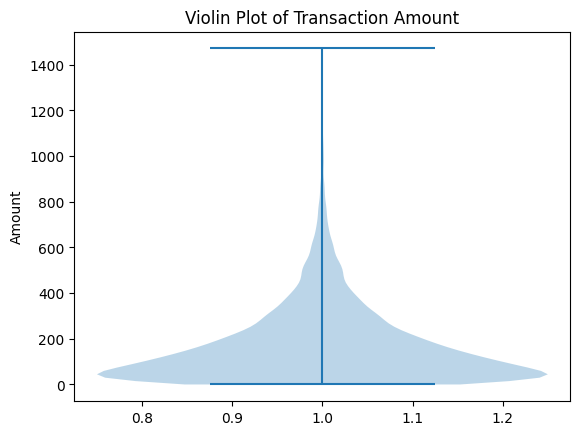

In [ ]:
plt.violinplot(credit['amount'])
plt.title('Violin Plot of Transaction Amount')
plt.ylabel('Amount')
plt.show()

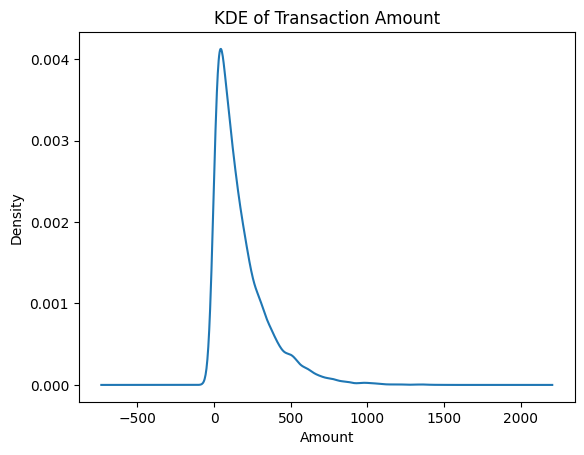

In [ ]:
credit['amount'].plot(kind="kde")
plt.title('KDE of Transaction Amount')
plt.xlabel('Amount')
plt.show()

#**Seaborn Plot**

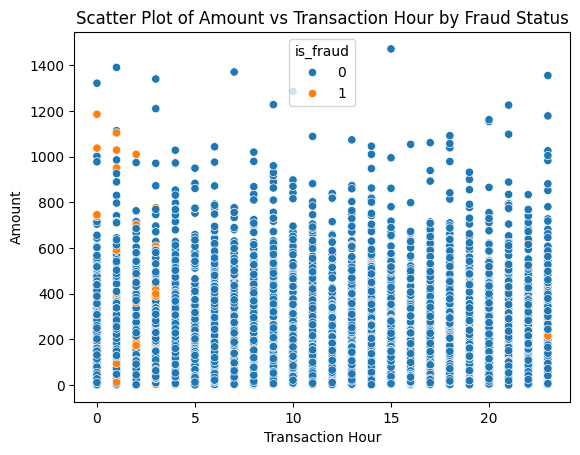

In [ ]:
sns.scatterplot(x=credit['transaction_hour'], y=credit['amount'], hue=credit['is_fraud'])
plt.title('Scatter Plot of Amount vs Transaction Hour by Fraud Status')
plt.xlabel('Transaction Hour')
plt.ylabel('Amount')
plt.show()

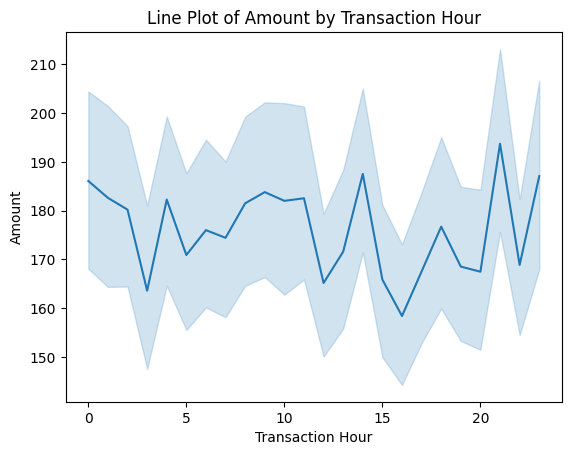

In [ ]:
sns.lineplot(x=credit['transaction_hour'], y=credit['amount'])
plt.title('Line Plot of Amount by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Amount')
plt.show()

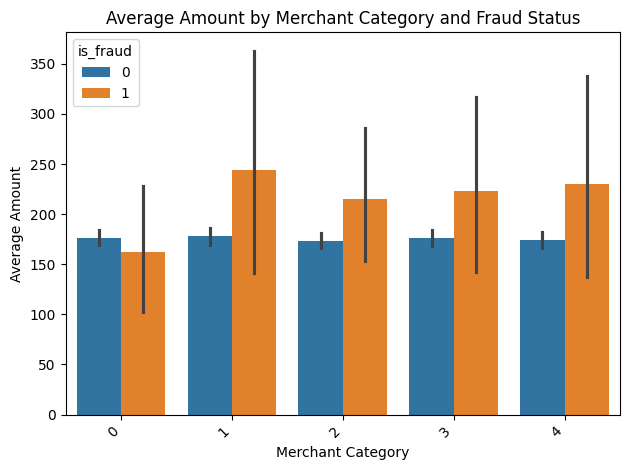

In [ ]:
sns.barplot(x=credit['merchant_category'], y=credit['amount'], hue=credit['is_fraud'], estimator=lambda x: x.mean())
plt.title('Average Amount by Merchant Category and Fraud Status')
plt.xlabel('Merchant Category')
plt.ylabel('Average Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

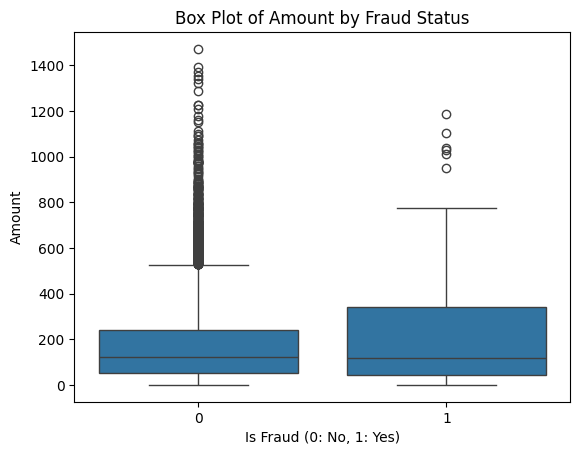

In [ ]:
sns.boxplot(x=credit['is_fraud'], y=credit['amount'])
plt.title('Box Plot of Amount by Fraud Status')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Amount')
plt.show()

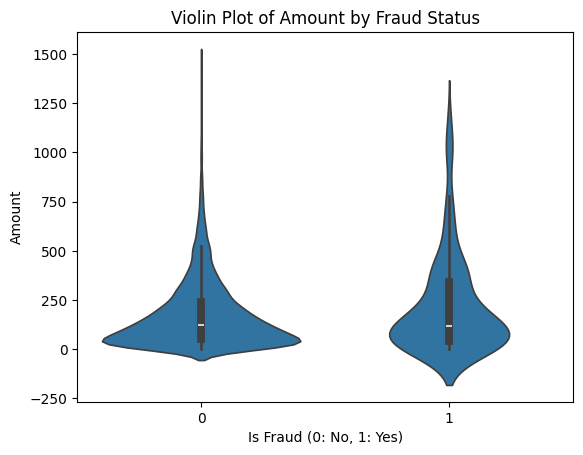

In [ ]:
sns.violinplot(x=credit['is_fraud'], y=credit['amount'])
plt.title('Violin Plot of Amount by Fraud Status')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Amount')
plt.show()

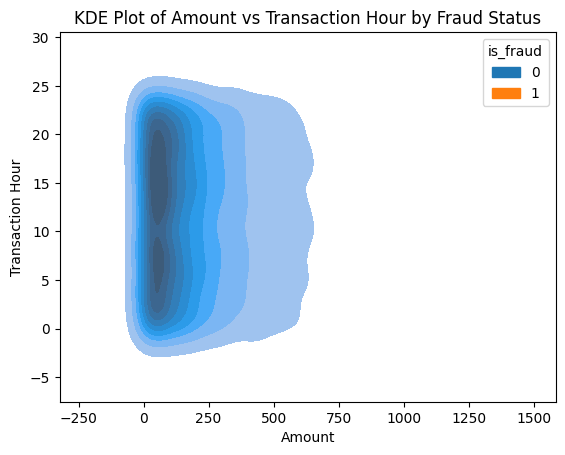

In [ ]:
sns.kdeplot(x=credit['amount'], y=credit['transaction_hour'], hue=credit['is_fraud'], fill=True)
plt.title('KDE Plot of Amount vs Transaction Hour by Fraud Status')
plt.xlabel('Amount')
plt.ylabel('Transaction Hour')
plt.show()

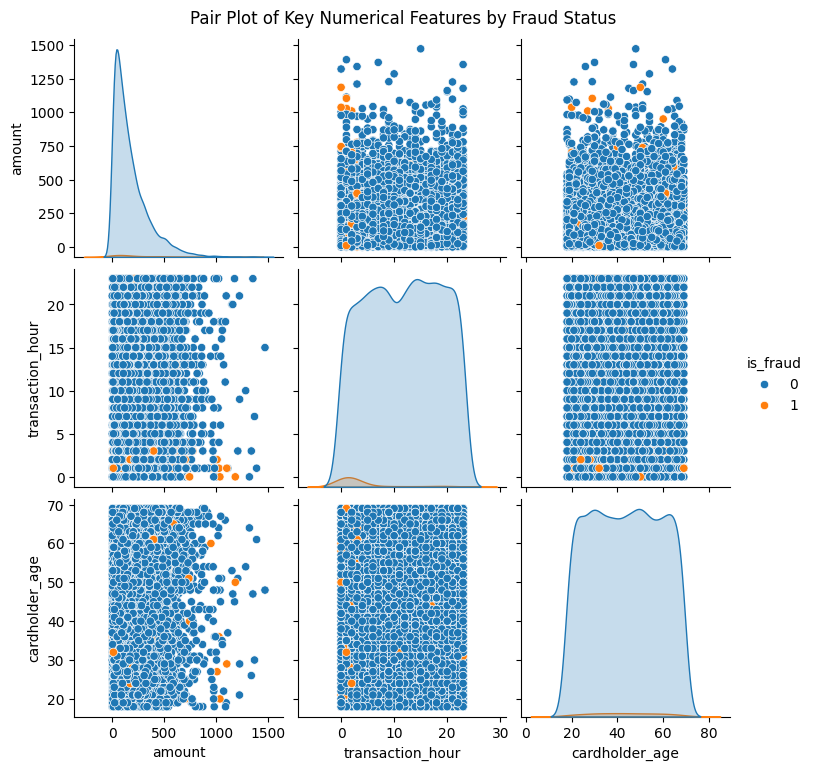

In [ ]:
sns.pairplot(credit[['amount', 'transaction_hour', 'cardholder_age', 'is_fraud']], hue='is_fraud')
plt.suptitle('Pair Plot of Key Numerical Features by Fraud Status', y=1.02)
plt.show()